# Assignment 11: Matplotlib (Core Plot Types & Visualization)

## Task 1: Line Plot (Sales Trend)

In [2]:
# Import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read Dataset
data=pd.read_csv('Superstore.csv',encoding='latin1')
df=pd.DataFrame(data)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
## Convert Order Date to datetime
df['Order Date']=pd.to_datetime(df['Order Date'])

In [6]:
## Create Month Column
df['Month']=df['Order Date'].dt.month_name()

In [7]:
## Show the new column Month
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October


In [8]:
## Monthly Sales total 
data=df.groupby('Month')['Sales'].sum()


In [9]:
data

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [10]:
data.index=pd.CategoricalIndex(data.index, categories=['January','February','March','April','May','June','July','August','September','October','November','December'])

In [11]:
## Convert the Month's name in sequence
data=data.sort_index()

In [12]:
data

Month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

In [13]:
## Provides the x-axis parameter ---> Month's name sequences
x=data.index

In [14]:
x


CategoricalIndex(['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November',
                  'December'],
                 categories=['January', 'February', 'March', 'April', ..., 'September', 'October', 'November', 'December'], ordered=False, dtype='category', name='Month')

In [15]:
## Provides the y-axis parameter----> Sales according to months order
y=data.values

In [16]:
y

array([ 94924.8356,  59751.2514, 205005.4888, 137762.1286, 155028.8117,
       152718.6793, 147238.097 , 159044.063 , 307649.9457, 200322.9847,
       352461.071 , 325293.5035])

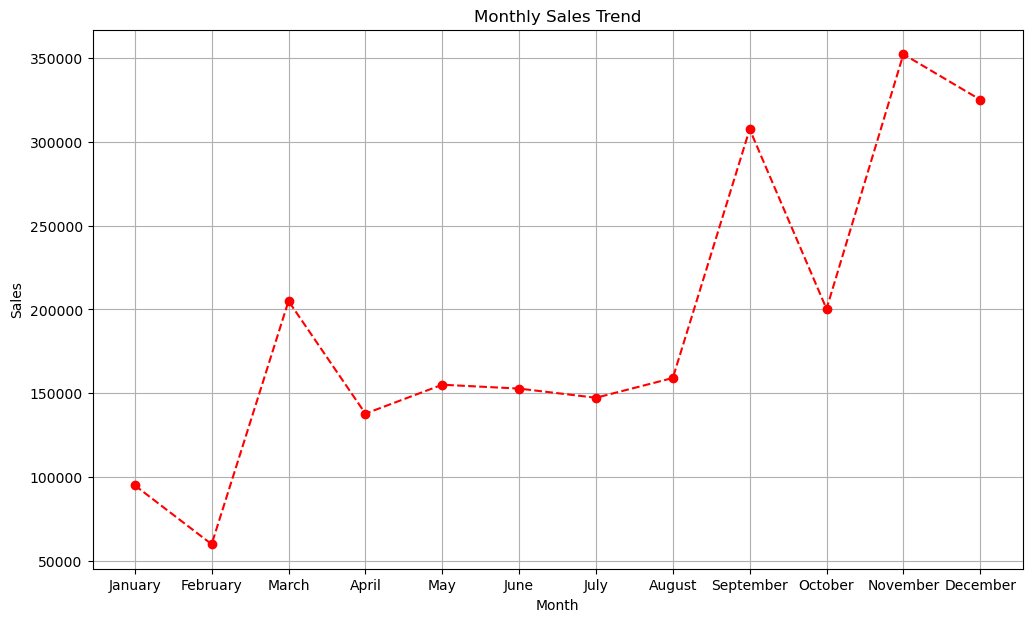

In [17]:
plt.figure(figsize=(12,7))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.plot(x,y,linewidth=1.5,linestyle='--',marker='o',color='red')
plt.grid()
plt.show()

## Task 2: Scatter Plot()

In [18]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
9237,9238,CA-2016-126732,2016-09-02,9/6/2016,Standard Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,West,OFF-BI-10001553,Office Supplies,Binders,SpineVue Locking Slant-D Ring Binders by Cardinal,7.312,1,0.2,2.5592,September
1573,1574,US-2014-157385,2014-11-23,11/25/2014,First Class,SC-20095,Sanjit Chand,Consumer,United States,Los Angeles,...,West,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,381.440,2,0.2,23.8400,November
4227,4228,CA-2015-154970,2015-01-05,1/10/2015,Standard Class,SR-20740,Steven Roelle,Home Office,United States,Seattle,...,West,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,61.584,1,0.2,-6.9282,January
7800,7801,CA-2017-157413,2017-06-01,6/6/2017,Standard Class,BW-11065,Barry Weirich,Consumer,United States,Philadelphia,...,East,OFF-ST-10002756,Office Supplies,Storage,"Tennsco Stur-D-Stor Boltless Shelving, 5 Shelv...",324.744,3,0.2,-77.1267,June
7657,7658,US-2014-120740,2014-04-15,4/15/2014,Same Day,PS-18970,Paul Stevenson,Home Office,United States,Los Angeles,...,West,FUR-FU-10004091,Furniture,Furnishings,"Howard Miller 13"" Diameter Goldtone Round Wall...",187.760,4,0.0,76.9816,April


In [19]:
# Create a Scatter plot showing relationship between the respective Numerical Columns

## Takes Profits as x-axis
x=df['Profit']
## Takes Sales as y-axis
y=df['Sales']

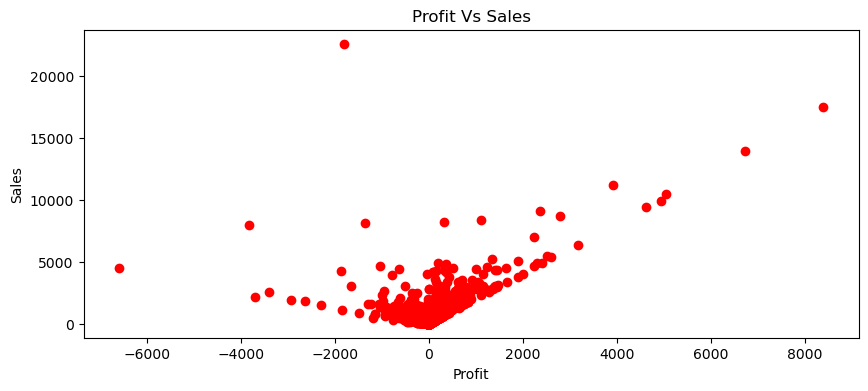

In [20]:
plt.figure(figsize=(10,4))
plt.title('Profit Vs Sales')
plt.xlabel('Profit')
plt.ylabel('Sales')
plt.scatter(x,y,color='red')
plt.show()

## Task 3: Bar Plot()

In [21]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
4466,4467,CA-2017-168641,2017-11-24,12/1/2017,Standard Class,KA-16525,Kelly Andreada,Consumer,United States,New York City,...,East,OFF-AR-10003759,Office Supplies,Art,"Crayola Anti Dust Chalk, 12/Pack",16.380,9,0.0,7.3710,November
7958,7959,CA-2017-131807,2017-10-05,10/10/2017,Standard Class,GG-14650,Greg Guthrie,Corporate,United States,Chico,...,West,FUR-FU-10004666,Furniture,Furnishings,DAX Clear Channel Poster Frame,72.900,5,0.0,26.9730,October
8271,8272,CA-2016-169670,2016-12-25,12/31/2016,Standard Class,JE-15715,Joe Elijah,Consumer,United States,New York City,...,East,FUR-CH-10002331,Furniture,Chairs,Hon 4700 Series Mobuis Mid-Back Task Chairs wi...,2563.056,8,0.1,313.2624,December
8599,8600,CA-2014-141110,2014-11-26,12/1/2014,Standard Class,LS-17200,Luke Schmidt,Corporate,United States,Fresno,...,West,OFF-PA-10002586,Office Supplies,Paper,Xerox 1970,14.940,3,0.0,7.0218,November
7844,7845,US-2017-123834,2017-07-21,7/25/2017,Standard Class,GM-14500,Gene McClure,Consumer,United States,Pharr,...,Central,FUR-TA-10001676,Furniture,Tables,Hon 61000 Series Interactive Training Tables,124.404,4,0.3,-21.3264,July


In [22]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [23]:
## Category Distribution based on total sales
data=df.groupby('Category')['Sales'].sum()

In [24]:
x=data.index
y=data.values

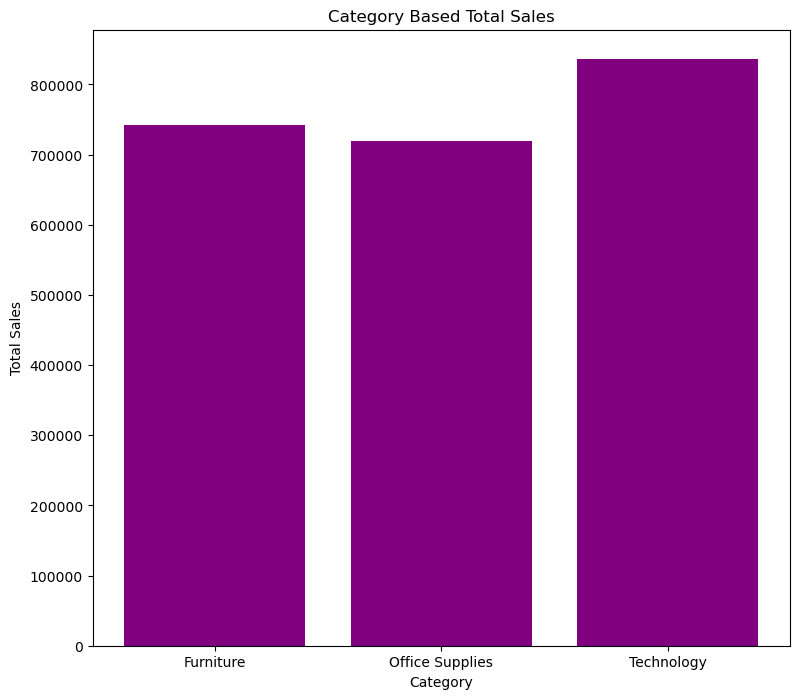

In [25]:
## Create a Vertical bar graph
plt.figure(figsize=(9,8))
plt.title('Category Based Total Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.bar(x,y,color='purple')
plt.show()

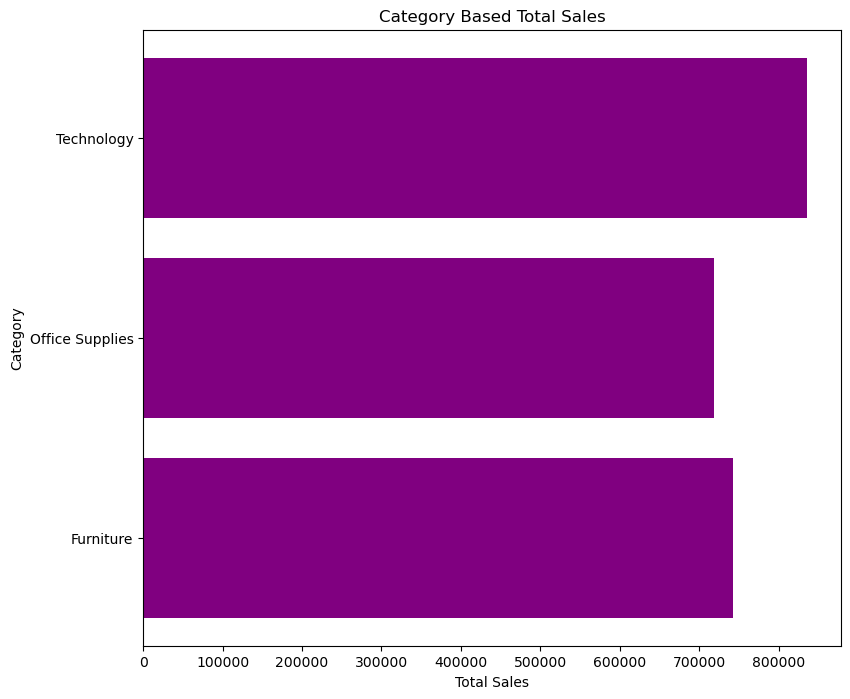

In [26]:
## Create a Horizontal bar graph
plt.figure(figsize=(9,8))
plt.title('Category Based Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.barh(x,y,color='purple')
plt.show()

## Task 4: Multiple Bar Plot()

In [27]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October


In [28]:
# Create Year Column
df['Year']=pd.to_datetime(df['Order Date']).dt.year

In [29]:
## Group Sales and Profit by Year
d=df.groupby('Year')['Sales'].sum()
m=df.groupby('Year')['Profit'].sum()

In [30]:
d

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [31]:
m

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

In [32]:
x=[2014, 2015, 2016, 2017]


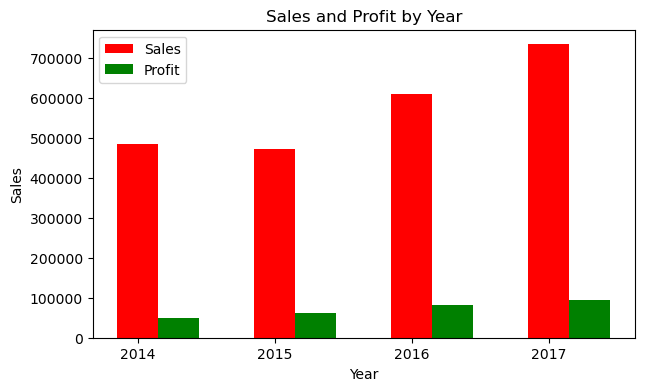

In [33]:
## Create Multiple Bar Chart
plt.figure(figsize=(7,4))
plt.title('Sales and Profit by Year')
plt.bar(np.arange(d.shape[0]) -0.3,d.values,width=0.3,color='red',label='Sales')
plt.bar(np.arange(d.shape[0]) ,m.values,width=0.3,color='green',label='Profit')
plt.xticks(np.arange(d.shape[0]) -0.3, x)
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Task 5: Stacked Bar Chart()

In [34]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
4195,4196,CA-2016-124233,2016-04-08,4/14/2016,Standard Class,CK-12595,Clytie Kelty,Consumer,United States,Los Angeles,...,FUR-FU-10002597,Furniture,Furnishings,"C-Line Magnetic Cubicle Keepers, Clear Polypro...",24.70,5,0.0,10.3740,April,2016
4205,4206,CA-2014-145387,2014-10-31,11/2/2014,Second Class,AM-10705,Anne McFarland,Consumer,United States,Cranston,...,FUR-FU-10002364,Furniture,Furnishings,"Eldon Expressions Wood Desk Accessories, Oak",14.76,2,0.0,4.2804,October,2014
8836,8837,US-2017-132675,2017-09-24,9/28/2017,Standard Class,KF-16285,Karen Ferguson,Home Office,United States,Sandy Springs,...,OFF-AR-10000034,Office Supplies,Art,"BIC Brite Liner Grip Highlighters, Assorted, 5...",12.72,3,0.0,4.9608,September,2017
6908,6909,US-2017-135503,2017-12-10,12/15/2017,Standard Class,JE-16165,Justin Ellison,Corporate,United States,North Charleston,...,FUR-FU-10002364,Furniture,Furnishings,"Eldon Expressions Wood Desk Accessories, Oak",14.76,2,0.0,4.2804,December,2017
9,10,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90,5,0.0,34.4700,June,2014


In [35]:
profit_values=df.groupby('Category')['Profit'].sum()

In [40]:
profit_values

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [41]:
discount_values=df.groupby('Category')['Discount'].sum()

In [42]:
discount_values

Category
Furniture          368.89
Office Supplies    947.80
Technology         244.40
Name: Discount, dtype: float64

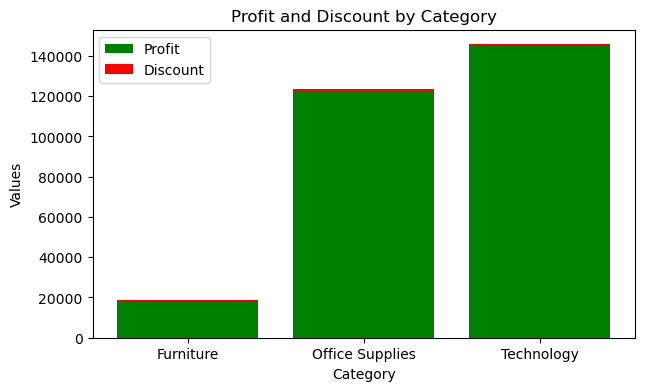

In [43]:
## Create a stacked bar chart 
plt.figure(figsize=(7,4))
plt.title('Profit and Discount by Category')
plt.xlabel('Category')
plt.ylabel('Values')
plt.bar(profit_values.index,profit_values.values,color='green',label='Profit')
plt.bar(discount_values.index,discount_values.values,color='red',label='Discount',bottom=profit_values.values)
plt.legend()
plt.show()

## Task 6: Histrogram (Marks Distribution)

In [ ]:
# Show that minimum value of Profit in dataset
df['Profit'].min()

-6599.978

In [ ]:
# Show that maximum values of Profit in dataset
df['Profit'].max()

8399.976

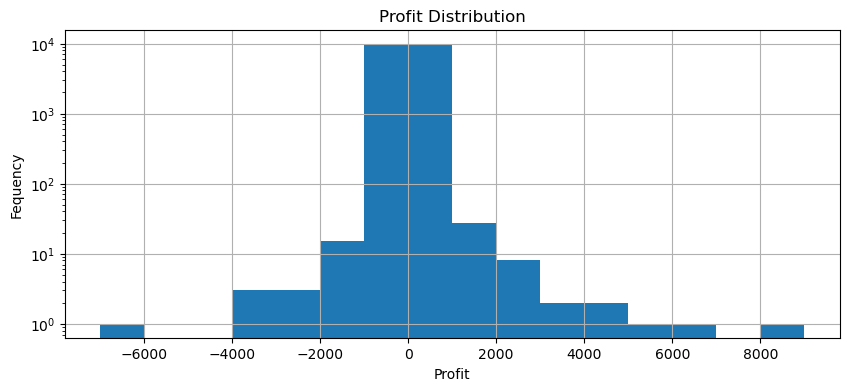

In [ ]:
## Histrogram Plot
plt.figure(figsize=(10,4))
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Fequency')
plt.hist(df['Profit'],bins=[-7000,-6000,-5000,-4000,-3000,-2000,-1000,1000,2000,3000,4000,5000,6000,7000,8000,9000],log=True)
plt.grid()
plt.show()

## Task 7: Pie Chart (Mark Share)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2016
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2016
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2016
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2015
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2015


In [ ]:
# Category wise sum of sales
data=df.groupby('Category')['Sales'].sum()

In [ ]:
data

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

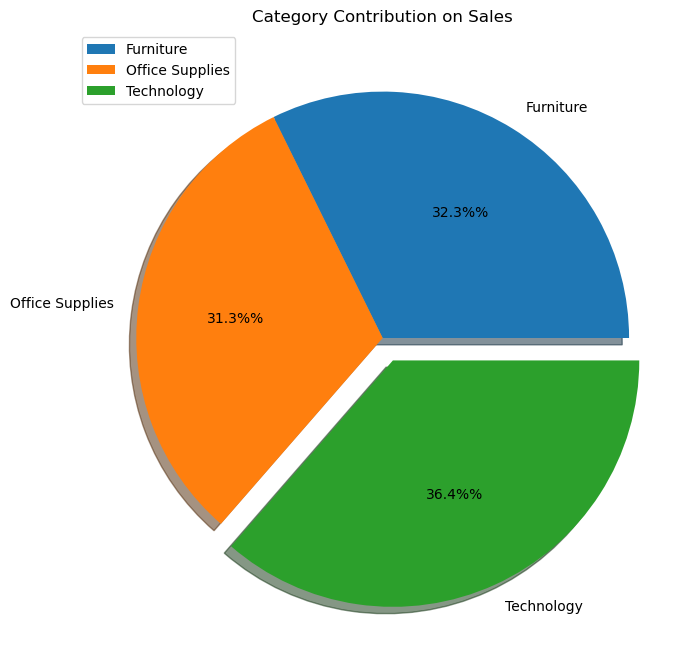

In [ ]:
# Pie Chart Plotting
plt.figure(figsize=(10,8))
plt.title('Category Contribution on Sales')
plt.pie(data, labels=data.index, autopct='%0.1f%%%%',explode=[0,0,0.1],shadow=True)
plt.legend()
plt.show()